In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/application_train.csv.zip')

print("Shape:", df.shape)
print("Default rate:", round(df.TARGET.mean()*100, 2), "%")
df.head()

Shape: (307511, 122)
Default rate: 8.07 %


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


Default rate: 8.07 %


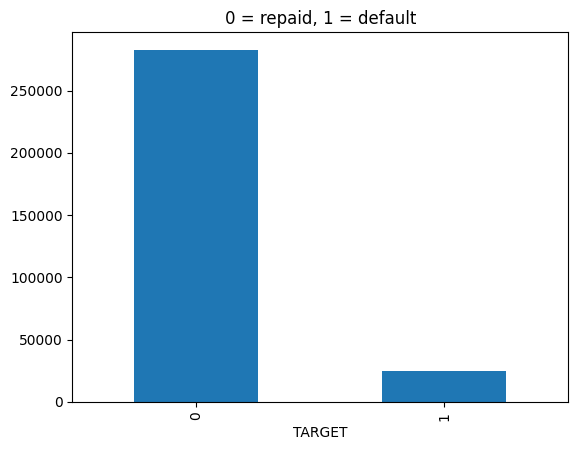


Top missing columns (%):
COMMONAREA_AVG              69.9
COMMONAREA_MODE             69.9
COMMONAREA_MEDI             69.9
NONLIVINGAPARTMENTS_MEDI    69.4
NONLIVINGAPARTMENTS_MODE    69.4
NONLIVINGAPARTMENTS_AVG     69.4
FONDKAPREMONT_MODE          68.4
LIVINGAPARTMENTS_AVG        68.4
LIVINGAPARTMENTS_MEDI       68.4
LIVINGAPARTMENTS_MODE       68.4
FLOORSMIN_MODE              67.8
FLOORSMIN_AVG               67.8
FLOORSMIN_MEDI              67.8
YEARS_BUILD_AVG             66.5
YEARS_BUILD_MODE            66.5
dtype: float64

AMT_INCOME_TOTAL — mean by group:
TARGET
0    169078.0
1    165612.0
Name: AMT_INCOME_TOTAL, dtype: float64

AMT_CREDIT — mean by group:
TARGET
0    602648.0
1    557779.0
Name: AMT_CREDIT, dtype: float64

DAYS_BIRTH — mean by group:
TARGET
0   -16138.0
1   -14885.0
Name: DAYS_BIRTH, dtype: float64


In [9]:
import matplotlib.pyplot as plt

# 1. Class balance — the key problem
print("Default rate:", round(df.TARGET.mean()*100, 2), "%")
df.TARGET.value_counts().plot(kind='bar', title='0 = repaid, 1 = default')
plt.show()

# 2. Missing values — top 15 worst columns
missing = (df.isna().mean()*100).sort_values(ascending=False).head(15)
print("\nTop missing columns (%):")
print(missing.round(1))

# 3. A few features vs default
for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'DAYS_BIRTH']:
    print(f"\n{col} — mean by group:")
    print(df.groupby('TARGET')[col].mean().round(0))

In [10]:
import numpy as np

# work on a copy
data = df.copy()

# 1. Convert DAYS_BIRTH to age (years)
data['AGE'] = (-data['DAYS_BIRTH'] / 365).round(1)

# 2. Drop columns that are >50% empty (too unreliable)
high_missing = data.columns[data.isna().mean() > 0.5]
data = data.drop(columns=high_missing)
print("Dropped", len(high_missing), "near-empty columns")

# 3. Split into features (X) and target (y)
X = data.drop(columns=['TARGET', 'SK_ID_CURR'])
y = data['TARGET']

# 4. Separate number columns from text columns
num_cols = X.select_dtypes(include='number').columns
cat_cols = X.select_dtypes(exclude='number').columns
print("Number cols:", len(num_cols), "| Text cols:", len(cat_cols))

Dropped 41 near-empty columns
Number cols: 67 | Text cols: 13


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

# split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# how to clean each column type
num_pipe = Pipeline([('impute', SimpleImputer(strategy='median')),
                     ('scale', StandardScaler())])
cat_pipe = Pipeline([('impute', SimpleImputer(strategy='most_frequent')),
                     ('encode', OneHotEncoder(handle_unknown='ignore'))])

prep = ColumnTransformer([('num', num_pipe, num_cols),
                          ('cat', cat_pipe, cat_cols)])

# baseline model — class_weight handles the 8% imbalance
logreg = Pipeline([('prep', prep),
                   ('model', LogisticRegression(max_iter=1000,
                                                class_weight='balanced'))])

logreg.fit(X_train, y_train)
probs = logreg.predict_proba(X_test)[:, 1]
print("Logistic Regression AUC:", round(roc_auc_score(y_test, probs), 4))

Logistic Regression AUC: 0.7455


In [12]:
from lightgbm import LGBMClassifier
from sklearn.preprocessing import LabelEncoder

# LightGBM handles missing values itself, but needs text as numbers
X_lgb = X.copy()
for col in cat_cols:
    X_lgb[col] = LabelEncoder().fit_transform(X_lgb[col].astype(str))

# same split
Xtr, Xte, ytr, yte = train_test_split(
    X_lgb, y, test_size=0.2, random_state=42, stratify=y)

# scale_pos_weight handles the 8% imbalance (92/8 ≈ 11.5)
lgb = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.02,
    num_leaves=34,
    scale_pos_weight=11.5,
    random_state=42)

lgb.fit(Xtr, ytr)
probs_lgb = lgb.predict_proba(Xte)[:, 1]
print("LightGBM AUC:", round(roc_auc_score(yte, probs_lgb), 4))

[LightGBM] [Info] Number of positive: 19860, number of negative: 226148
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.209275 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4437
[LightGBM] [Info] Number of data points in the train set: 246008, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432482
[LightGBM] [Info] Start training from score -2.432482
LightGBM AUC: 0.7568


                       feature  importance
39                EXT_SOURCE_3        1422
38                EXT_SOURCE_2        1164
6                   AMT_CREDIT        1073
7                  AMT_ANNUITY        1017
8              AMT_GOODS_PRICE         939
16               DAYS_EMPLOYED         841
18             DAYS_ID_PUBLISH         740
52      DAYS_LAST_PHONE_CHANGE         636
15                  DAYS_BIRTH         596
17           DAYS_REGISTRATION         560
5             AMT_INCOME_TOTAL         514
46              TOTALAREA_MODE         495
79                         AGE         473
14  REGION_POPULATION_RELATIVE         431
25             OCCUPATION_TYPE         315


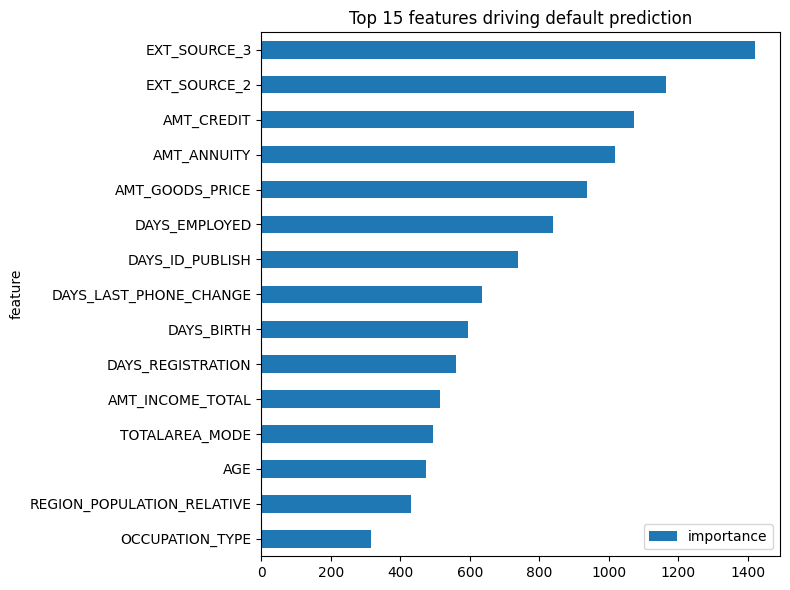

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

imp = pd.DataFrame({
    'feature': X_lgb.columns,
    'importance': lgb.feature_importances_
}).sort_values('importance', ascending=False).head(15)

print(imp)

imp.plot(kind='barh', x='feature', y='importance', figsize=(8,6),
         title='Top 15 features driving default prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [14]:
import joblib

# retrain on ALL data for the final saved model
lgb_final = LGBMClassifier(
    n_estimators=500, learning_rate=0.02, num_leaves=34,
    scale_pos_weight=11.5, random_state=42)
lgb_final.fit(X_lgb, y)

# save model + the exact column order the app must feed in
joblib.dump(lgb_final, 'model.pkl')
joblib.dump(list(X_lgb.columns), 'columns.pkl')

# save the text-column categories so the app can encode inputs the same way
cat_maps = {col: list(df[col].dropna().unique()) for col in cat_cols}
joblib.dump(cat_maps, 'cat_maps.pkl')

print("Saved: model.pkl, columns.pkl, cat_maps.pkl")
from google.colab import files
files.download('model.pkl')
files.download('columns.pkl')
files.download('cat_maps.pkl')


[LightGBM] [Info] Number of positive: 24825, number of negative: 282686
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.311191 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4366
[LightGBM] [Info] Number of data points in the train set: 307511, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.080729 -> initscore=-2.432486
[LightGBM] [Info] Start training from score -2.432486
Saved: model.pkl, columns.pkl, cat_maps.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>